In [1820]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D


In [1821]:
def p_field(p_spec):
    return np.array(p_spec["phi"], dtype=float)

def wind_field_star(wind_spec):
    return np.array(wind_spec["u_star"], dtype=float)

def odes_star(tau, y, Gamma, Lambda, wind_spec):
    x, y_, z, vx, vy, vz = y
    v = np.array([vx, vy, vz])
    u = wind_field_star(wind_spec)

    vrel = v - u
    speed = np.linalg.norm(vrel)

    dxdt = vx
    dydt = vy
    dzdt = vz

    dvxdt = -Lambda * speed * vrel[0]
    dvydt = -Lambda * speed * vrel[1]
    dvzdt = -Gamma - Lambda * speed * vrel[2]

    return [dxdt, dydt, dzdt, dvxdt, dvydt, dvzdt]


In [1822]:
def hit_ground(tau, y):
    return y[2]

hit_ground.terminal = True
hit_ground.direction = -1


In [1823]:
def initial_velocity(theta, phi):
    return np.array([
        np.cos(theta)*np.cos(phi),
        np.cos(theta)*np.sin(phi),
        np.sin(theta)
    ])


In [1824]:
def simulate(theta, phi, Gamma, Lambda, wind_spec,
             z0_star=0.0, tau_max=30.0):

    y0 = np.zeros(6)
    y0[0:3] = [0.0, 0.0, z0_star]
    y0[3:6] = initial_velocity(theta, p_field(phi))

    sol = solve_ivp(
        lambda t, y: odes_star(t, y, Gamma, Lambda, wind_spec),
        (0, tau_max),
        y0,
        events=hit_ground,
        rtol=1e-4,
        atol=1e-6,
        max_step=0.05
    )

    if sol.status != 1:
        return None, None

    xL, yL = sol.y[0, -1], sol.y[1, -1]
    rL = np.hypot(xL, yL)
    psiL = np.arctan2(yL, xL)

    return sol, {"xL": xL, "yL": yL, "rL": rL, "psiL": psiL}


In [1825]:
Gamma  = 0.12    # gravity strength
Lambda = 0.15    # drag strength (increased → less overshoot)
z0_star = 0.0


In [1826]:
Gamma  = 0.40      # stronger gravity relative to launch speed
Lambda = 0.40      # strong drag

theta = np.deg2rad(75)
phi   = [
    {"phi": 0.0},
    {"phi": 2*np.pi/5},
    {"phi": 4*np.pi/5},
    {"phi": 6*np.pi/5},
    {"phi": 8*np.pi/5},
]  # different launch directions based on different spoke positions

winds = [
    {"u_star": (0.0, 0.0, 0.0)},
    {"u_star": (0.05, 0.0, 0.0)},
    {"u_star": (0.10, 0.0, 0.0)},
    {"u_star": (0.15, 0.0, 0.0)},
    {"u_star": (0.20, 0.0, 0.0)},
    {"u_star": (0.25, 0.0, 0.0)},
    {"u_star": (0.40, 0.0, 0.0)},
    {"u_star": (0.50, 0.0, 0.0)},
] # keeping and inc wind in x direction

colors = ["red", "orange", "yellow", "green", "cyan", "blue", "purple", "magenta"]

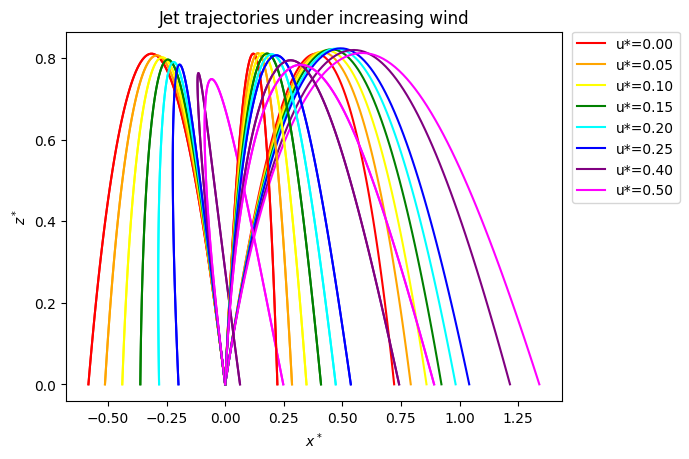

In [1827]:
plt.figure()
for i, p in enumerate(phi):
    for j, w in enumerate(winds):
        sol, _ = simulate(theta, p, Gamma, Lambda, w)
        if sol is not None:
            if i == 0:
                plt.plot(sol.y[0], sol.y[2], color=colors[j],
                        label=f"u*={w['u_star'][0]:.2f}")
            else:
                plt.plot(sol.y[0], sol.y[2], color=colors[j])

plt.xlabel(r"$x^*$")
plt.ylabel(r"$z^*$")
plt.title("Jet trajectories under increasing wind")
plt.legend(loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0)
plt.show()


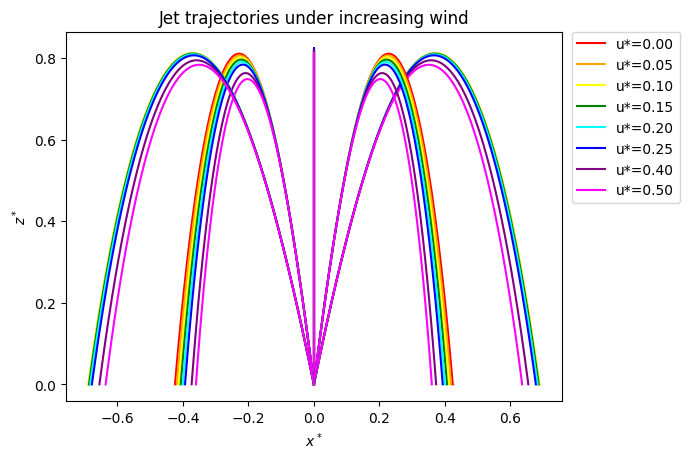

In [1828]:
plt.figure()
for i, p in enumerate(phi):
    for j, w in enumerate(winds):
        sol, _ = simulate(theta, p, Gamma, Lambda, w)
        if sol is not None:
            if i == 0:
                plt.plot(sol.y[1], sol.y[2], color=colors[j],
                        label=f"u*={w['u_star'][0]:.2f}")
            else:
                plt.plot(sol.y[1], sol.y[2], color=colors[j])

plt.xlabel(r"$x^*$")
plt.ylabel(r"$z^*$")
plt.title("Jet trajectories under increasing wind")
plt.legend(loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0)
plt.show()

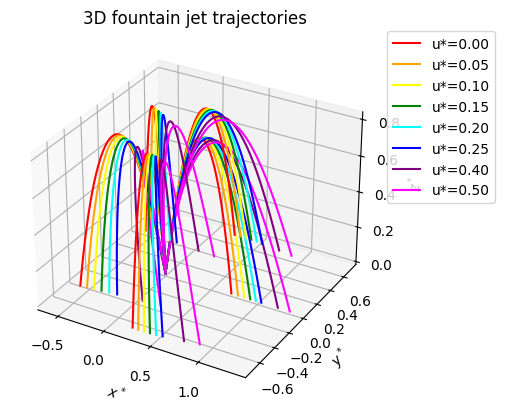

In [1829]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

for i, p in enumerate(phi):
    for j, w in enumerate(winds):
        sol, _ = simulate(theta, p, Gamma, Lambda, w)
        if sol is not None:
            if i == 0:
                ax.plot(
                    sol.y[0],  # x*
                    sol.y[1],  # y*
                    sol.y[2],  # z*
                    color=colors[j],
                    label=f"u*={w['u_star'][0]:.2f}"
                )
            else:
                ax.plot(
                    sol.y[0],  # x*
                    sol.y[1],  # y*
                    sol.y[2],  # z*
                    color=colors[j],
                )

ax.set_xlabel(r"$x^*$")
ax.set_ylabel(r"$y^*$")
ax.set_zlabel(r"$z^*$")
ax.set_title("3D fountain jet trajectories")
ax.legend(loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0)

plt.show()


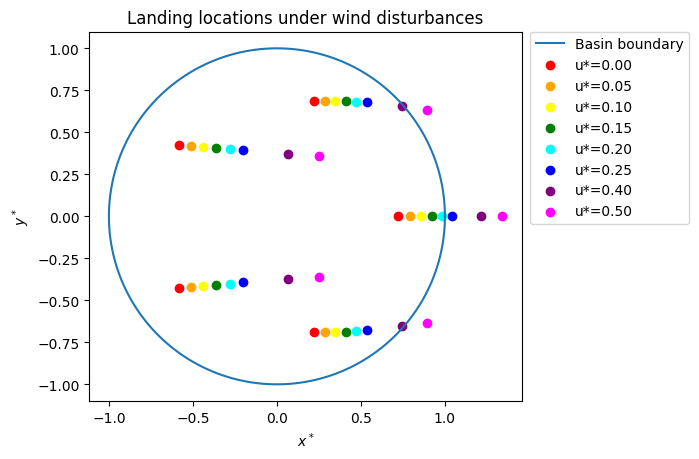

In [1830]:
theta_circ = np.linspace(0, 2*np.pi, 400)
plt.figure()
plt.plot(np.cos(theta_circ), np.sin(theta_circ), label="Basin boundary")

for i, p in enumerate(phi):
    for j, w in enumerate(winds):
        xs, ys = [], []
        _, land = simulate(theta, p, Gamma, Lambda, w)
        if land:
            xs.append(land["xL"])
            ys.append(land["yL"])

            if i == 0:
                plt.scatter(xs, ys,
                    color=colors[j],
                    label=f"u*={w['u_star'][0]:.2f}")
            else:
                plt.scatter(xs, ys,
                    color=colors[j])

plt.gca().set_aspect("equal")
plt.xlabel(r"$x^*$")
plt.ylabel(r"$y^*$")
plt.title("Landing locations under wind disturbances")
plt.legend(loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0)
plt.show()


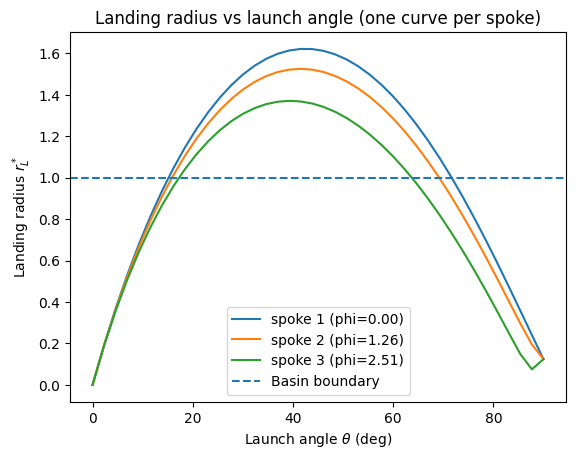

In [1831]:
angles = np.deg2rad(np.linspace(0, 90, 40))
wind_fixed = {"u_star": (0.1, 0.0, 0.0)}

rvals = np.full((len(phi), len(angles)), np.nan)

for j, p in enumerate(phi):
    for i, th in enumerate(angles):
        _, land = simulate(th, p, Gamma, Lambda, wind_fixed)
        if land is not None:
            rvals[j, i] = land["rL"]

plt.figure()
for j, p in enumerate(phi):
    if j == 3:
        break
    plt.plot(np.rad2deg(angles), rvals[j], label=f"spoke {j+1} (phi={p['phi']:.2f})")

plt.axhline(1.0, linestyle="--", label="Basin boundary")
plt.xlabel(r"Launch angle $\theta$ (deg)")
plt.ylabel(r"Landing radius $r_L^*$")
plt.title("Landing radius vs launch angle (one curve per spoke)")
plt.legend()
plt.show()


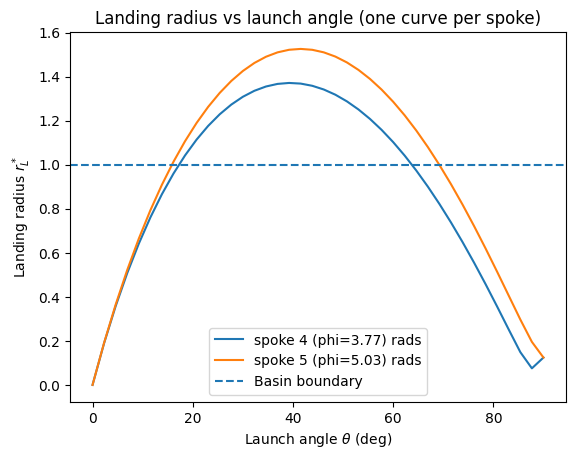

In [1832]:
plt.figure()
for j, p in enumerate(phi):
    if j < 3:
        continue
    plt.plot(np.rad2deg(angles), rvals[j], label=f"spoke {j+1} (phi={p['phi']:.2f}) rads")

plt.axhline(1.0, linestyle="--", label="Basin boundary")
plt.xlabel(r"Launch angle $\theta$ (deg)")
plt.ylabel(r"Landing radius $r_L^*$")
plt.title("Landing radius vs launch angle (one curve per spoke)")
plt.legend()
plt.show()

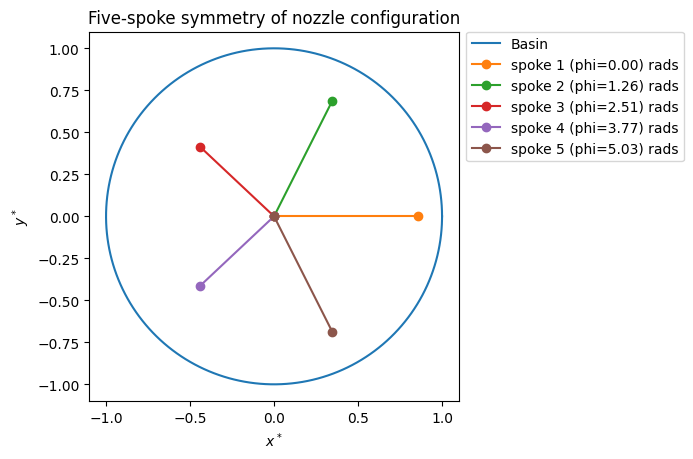

In [1833]:
plt.figure()
plt.plot(np.cos(theta_circ), np.sin(theta_circ), label="Basin")

for j, p in enumerate(phi):
    _, land = simulate(theta, p, Gamma, Lambda, wind_fixed)
    if land:
        plt.plot([0, land["xL"]], [0, land["yL"]], marker="o", label=f"spoke {j+1} (phi={p['phi']:.2f}) rads")

plt.gca().set_aspect("equal")
plt.xlabel(r"$x^*$")
plt.ylabel(r"$y^*$")
plt.title("Five-spoke symmetry of nozzle configuration")
plt.legend(loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0)
plt.show()


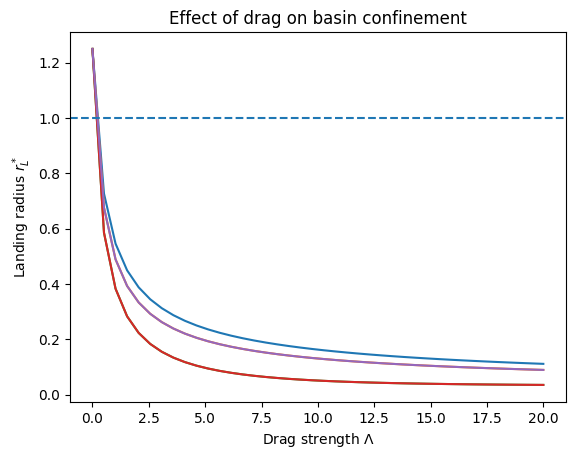

In [1834]:
Lambdas = np.linspace(0.0, 20, 40)
rvals = np.full((len(phi), len(Lambdas)), np.nan)

wind_fixed = {"u_star": (0.05, 0.0, 0.0)}

for i, Lam in enumerate(Lambdas):
    for j, p in enumerate(phi):
        _, land = simulate(theta, p, Gamma, Lam, wind_fixed)
        if land is not None:
            rvals[j, i] = land["rL"]

for j, p in enumerate(phi):
    plt.plot(Lambdas, rvals[j], label=f"spoke {j+1} (phi={p['phi']:.2f})")
plt.axhline(1.0, linestyle="--")
plt.xlabel(r"Drag strength $\Lambda$")
plt.ylabel(r"Landing radius $r_L^*$")
plt.title("Effect of drag on basin confinement")
plt.show()


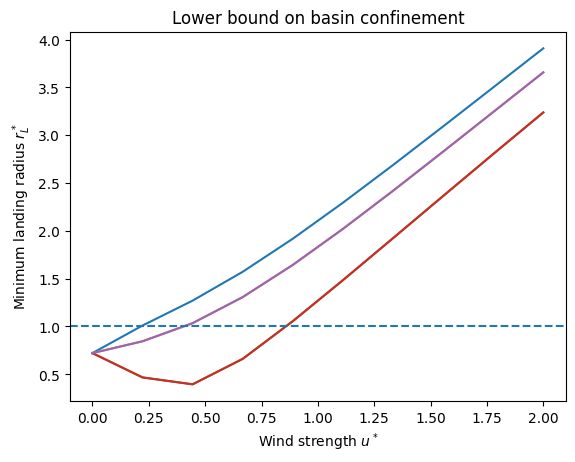

In [1835]:
winds = np.linspace(0.0, 2, 10)
rmin = np.full((len(phi), len(winds)), np.nan)

for i, U in enumerate(winds):
    for j, p in enumerate(phi):
        _, land = simulate(theta, p, Gamma, Lambda,
                        {"u_star": (U, 0.0, 0.0)})
        if land is not None:
            rmin[j, i] = land["rL"]

for j, p in enumerate(phi):
    plt.plot(winds, rmin[j], label=f"spoke {j+1} (phi={p['phi']:.2f})")
plt.axhline(1.0, linestyle="--")
plt.xlabel("Wind strength $u^*$")
plt.ylabel("Minimum landing radius $r_L^*$")
plt.title("Lower bound on basin confinement")
plt.show()


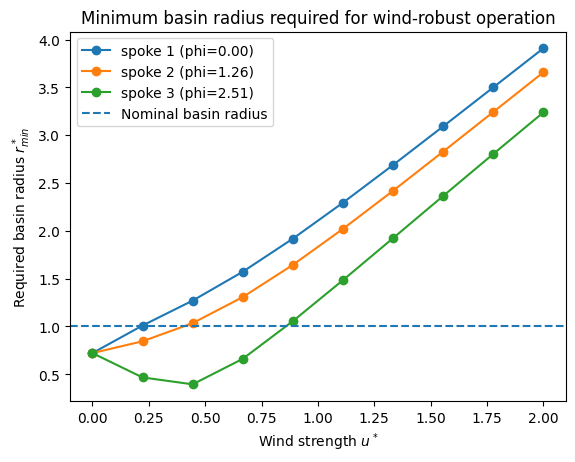

In [1836]:
winds = np.linspace(0.0, 2, 10)
r_required = np.full((len(phi), len(winds)), np.nan)

for i, U in enumerate(winds):
    for j, p in enumerate(phi):
        _, land = simulate(theta, p, Gamma, Lambda,
                        {"u_star": (U, 0.0, 0.0)})
        if land is not None:
            r_required[j, i] = land["rL"]

plt.figure()
for j, p in enumerate(phi):
    if j == 3:
        break
    plt.plot(winds, r_required[j], label=f"spoke {j+1} (phi={p['phi']:.2f})", marker="o")
plt.axhline(1.0, linestyle="--", label="Nominal basin radius")
plt.xlabel("Wind strength $u^*$")
plt.ylabel("Required basin radius $r_{min}^*$")
plt.title("Minimum basin radius required for wind-robust operation")
plt.legend()
plt.show()


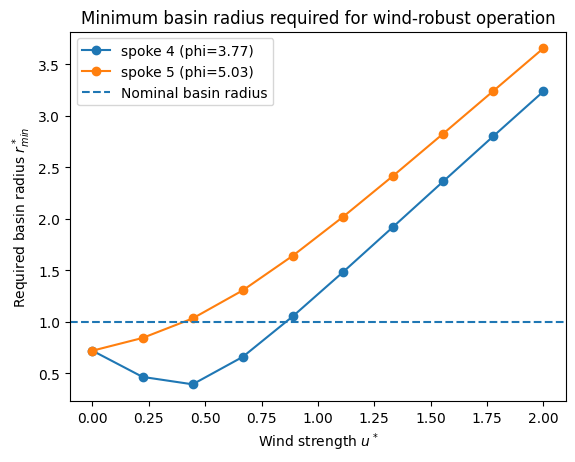

In [1837]:
plt.figure()
for j, p in enumerate(phi):
    if j < 3:
        continue
    plt.plot(winds, r_required[j], label=f"spoke {j+1} (phi={p['phi']:.2f})", marker="o")
plt.axhline(1.0, linestyle="--", label="Nominal basin radius")
plt.xlabel("Wind strength $u^*$")
plt.ylabel("Required basin radius $r_{min}^*$")
plt.title("Minimum basin radius required for wind-robust operation")
plt.legend()
plt.show()